<img src='https://seaborn.pydata.org/_static/logo-wide-lightbg.svg' width=500/>

# 2.시각화 라이브러리 : seaborn

- matplotlib을 좀 더 쉽고 아름답게 시각화하는 **matplotlib** 기반의 시각화 라이브러리
- 실제 분석에서는 **seaborn**과 **matplotlib**을 함께 사용하여 시각화하는 경우가 많다.
- https://seaborn.pydata.org/

## 2.1.환경준비

**1) 다양한 그래프들**
- https://seaborn.pydata.org/examples/

**2) seaborn 자체 데이터셋**
- https://github.com/mwaskom/seaborn-data

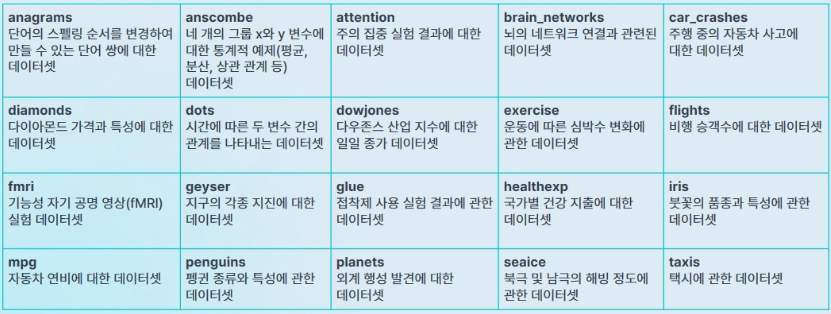

* 라이브러리 불러오기

In [35]:
import warnings

warnings.filterwarnings('ignore')

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# seaborn 내장 데이터의 종류
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [38]:
# 타이타닉 데이터
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [55]:
# iris 분류 데이터
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [40]:
# 팁 데이터
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 2.2. seaborn 다양한 차트들

### 2.2.1. 기본 차트들

**1) histogram : sns.histplot**

- https://seaborn.pydata.org/generated/seaborn.histplot.html

- histplot( ) 함수의 매개변수

    - data : 히스토그램을 그릴 데이터셋을 지정

    - bins : 히스토그램에서 막대의 개수를 지정

    - kde : True로 설정하면 커널 밀도 추정(KDE) 곡선을 히스토그램 위에 추가

- 히스토그램
    - 연속형 데이터를 일정한 간격으로 나누어 각 구간에 속하는 데이터 빈도를 막대로 표현한 그래프
    - 각 막대는 데이터 분포를 나타내며 높이는 해당 구간의 데이터 개수를 나타낸다.

- 커널 밀도 추정 그래프
    - 데이터 분포를 나타낸다는 점에서 히스토그램과 비슷하다.
    - 그러나 막대 그래프 대신 부드러운 곡선을 사용하는데, 이는 커널 함수 덕분에 가능하다.
    - 커널 함수는 각 데이터 포인트 주위에 작은 확률 분포를 만들고, 이를 모두 합하여 전체 데이터의 분포를 표현한다.

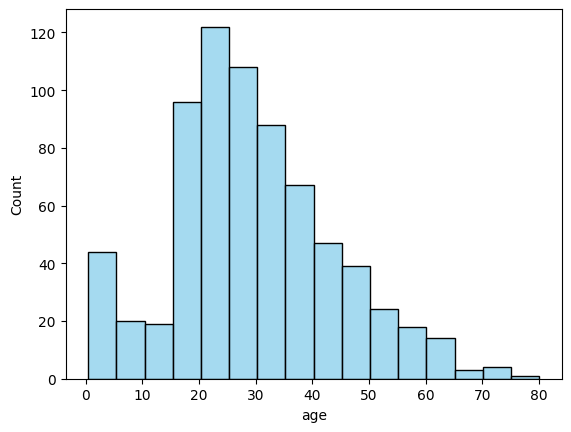

In [41]:
sns.histplot(data=titanic['age'], bins=16, color='skyblue')
plt.show()

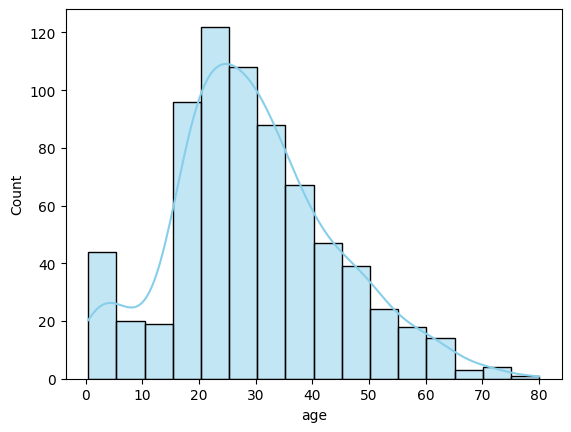

In [42]:
sns.histplot(data=titanic['age'], bins=16, kde=True, color='skyblue')
plt.show()

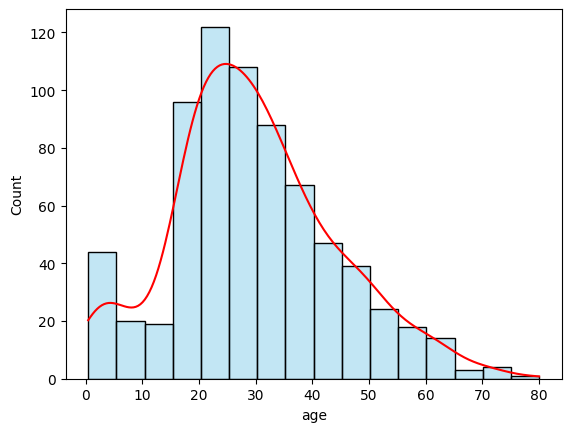

In [43]:
ax = sns.histplot(data=titanic['age'], bins=16, kde=True, color='skyblue')
ax.lines[0].set_color('red')
plt.show()

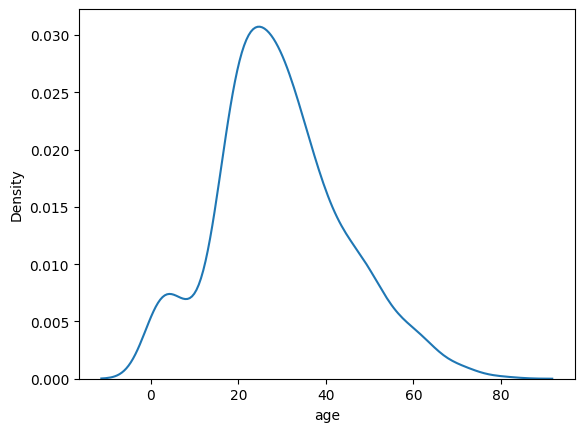

In [44]:
sns.kdeplot(data=titanic, x='age')
plt.show()

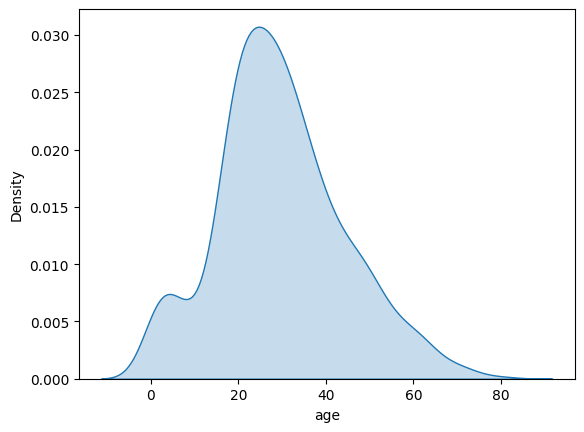

In [45]:
sns.kdeplot(data=titanic, x='age', fill=True)
plt.show()

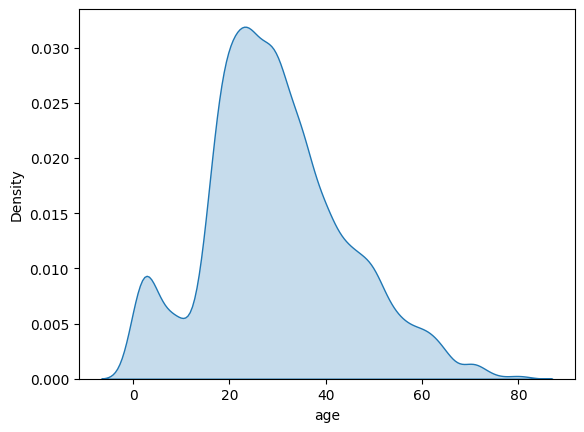

In [46]:
sns.kdeplot(data=titanic, x='age', fill=True, bw_adjust=0.6)
plt.show()

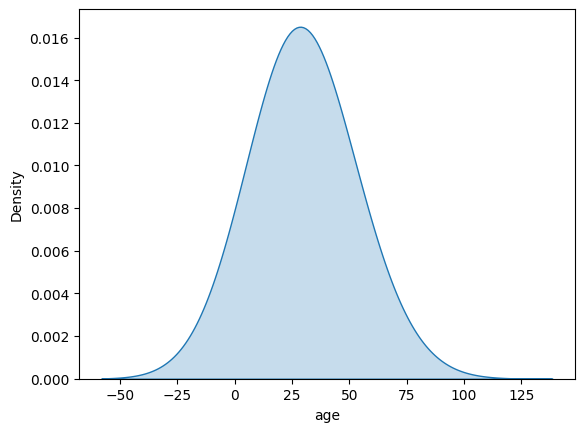

In [47]:
sns.kdeplot(data=titanic, x='age', fill=True, bw_adjust=5)
# bw -> band width
plt.show()

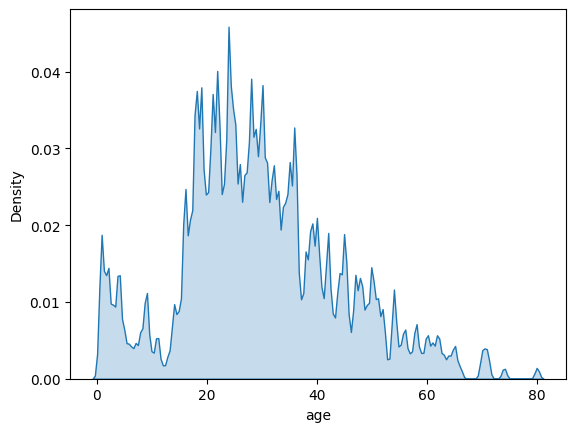

In [48]:
sns.kdeplot(data=titanic, x='age', fill=True, bw_adjust=.1)
plt.show()

**2) densityplot : sns.kdeplot**

- https://seaborn.pydata.org/generated/seaborn.kdeplot.html

- kdeplot( ) 함수의 매개변수

    - data : 사용한 데이터프레임

    - hue : 그룹별로 색상을 나눔

    - fill : 밀도 아래 영역을 채움

    - bw_adjust : 커널의 너비 조정 (값이 작을수록 더 세밀함)

    - common_norm : 그룹별 밀도 곡선의 정규화(Normalization) 방식을 설정

        - 정규화(Normalization): 밀도 곡선을 그릴 때, 곡선 아래 면적의 총합이 1이 되도록 스케일을 맞추는 과정  

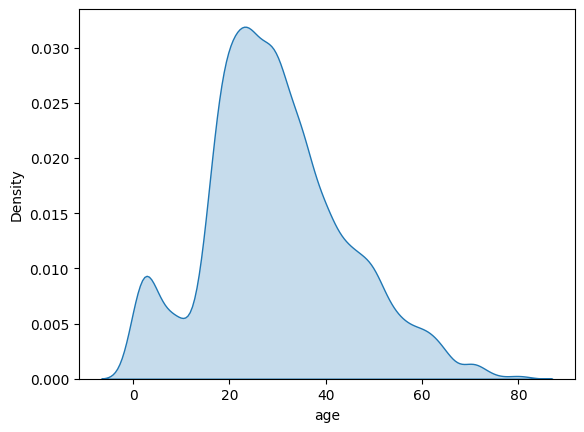

In [49]:
sns.kdeplot(data=titanic, x='age', fill=True, bw_adjust=0.6)
plt.show()

**3) boxplot**

- https://seaborn.pydata.org/generated/seaborn.boxplot.html

- 주로 범주형 데이터와 연속형 데이터 간의 관계를 나타낼 때 유용

- 이상치
  1. 오류로 생긴 이상치
    - 나이를 25세가 아니라 250세로 잘못 입력
    - 센서 오작동으로 말도 안 되는 값 기록

  2. 실제로 존재하는 극단값 (먼저 확인해야 할 값)
    - 고객의 소득이나 자산
    - VIP 고객의 고액 결제
    - 블랙프라이데이 매출 급증
    - 신용카드 이상 거래 탐지

- boxplot( ) 함수의 매개변수

    - data : 사용한 데이터프레임

    - hue : 그룹을 나눌 기준 변수

    - order : x축 범주의 순서 지정

    - width : 박스 너비 조정 (기본값: 0.8)

    - showfliers : 이상치(outliers) 표시 여부 (기본값: True)
    

**[상자 그림]**
![이미지](https://miro.medium.com/max/8100/1*NRlqiZGQdsIyAu0KzP7LaQ.png)

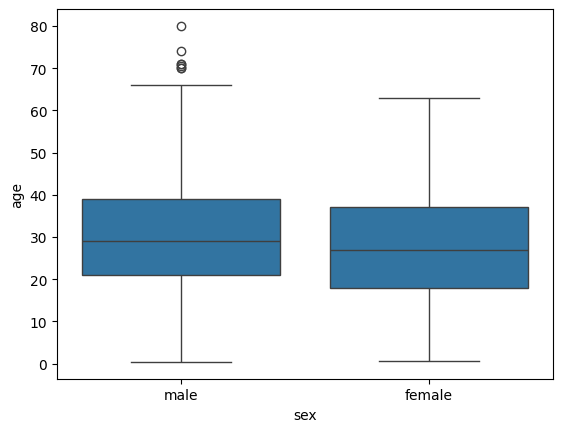

In [50]:
sns.boxplot(data=titanic, x='sex', y='age')
plt.show()

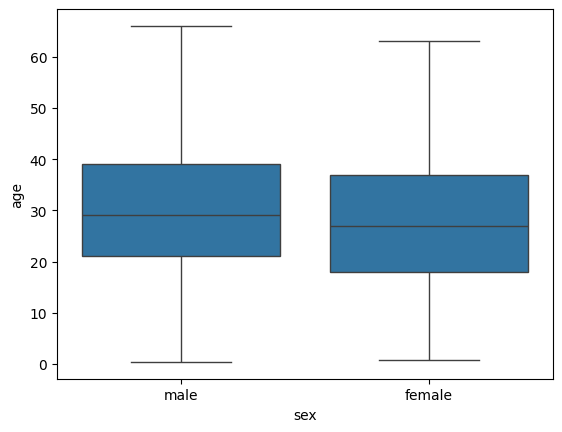

In [51]:
sns.boxplot(data=titanic, x='sex', y='age', showfliers=False)
plt.show()

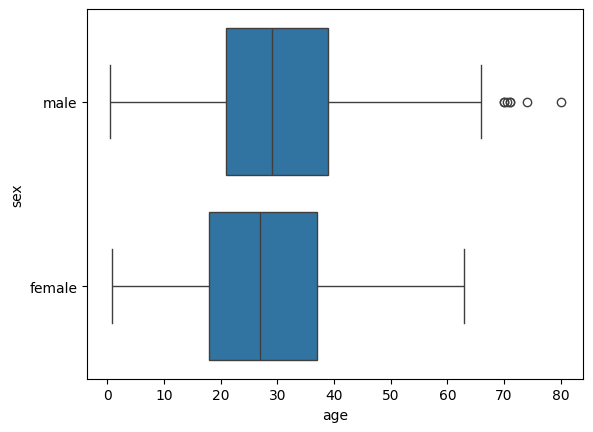

In [52]:
# 가로 방향 박스 플롯
sns.boxplot(data=titanic, y='sex', x='age', orient='h') # orient='h' : 박스플롯을 가로로
plt.show()

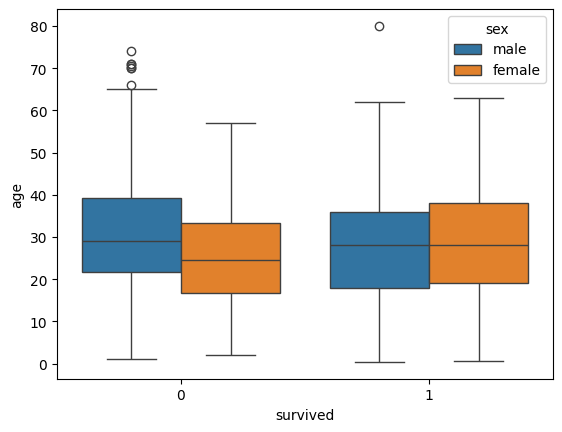

In [53]:
sns.boxplot(data=titanic, x='survived', y='age', hue='sex')
plt.show()

### **2.2.2. jointplot : scatter + histogram(혹은 density plot)**

- https://seaborn.pydata.org/generated/seaborn.jointplot.html

- 두 숫자형 변수의 분포를 산점도와 히스토그램으로 함께 시각화하여 데이터 간의 관계를 확인 할 수 있다.

- Seaborn 그래프의 가장 큰 특징은 hue 옵션으로 범주 차원을 추가해서 볼 수 있다.




- jointplot( ) 함수의 매개변수

    - x, y : x축과 y축에 사용할 변수

    - data : 히스토그램을 그릴 데이터셋을 지정

    - kind : 결합 플롯의 유형을 지정
        - scatter(산점도 플롯), kde(커널 밀도 추정 그래프), hex(육각형 바이닝 플롯), reg(회귀선을 포    함한 산점도 플롯), resid(회귀 분석 잔차 플롯)

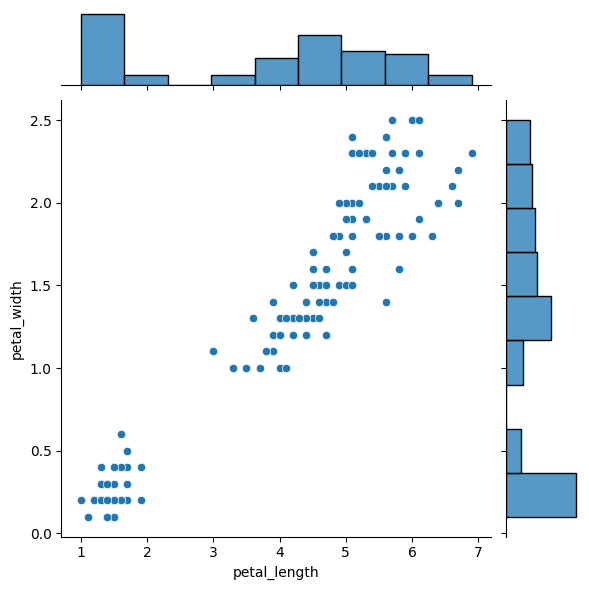

In [57]:
sns.jointplot(x='petal_length', y='petal_width', data=iris, kind='scatter')
plt.show()

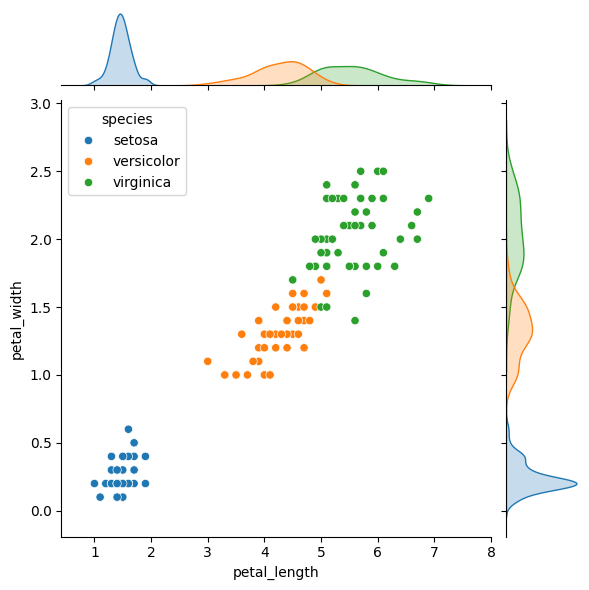

In [58]:
sns.jointplot(x='petal_length', y='petal_width', data=iris, kind='scatter', hue='species')
plt.show()

### **2.2.3. regplot : scatter + regression**

- https://seaborn.pydata.org/generated/seaborn.regplot.html

- 두 숫자형 변수의 산점도와 회귀선을 한꺼번에 비교하여  보여준다.

- 두 변수 간의 선형 관계를 시각화하는데 사용



- regplot() 함수의 매개변수

    - x : x축에 사용할 변수

    - y : y축에 사용할 변수

    - data : 시각화할 데이터를 포함하는 데이터프레임을 지정

    - fit_reg : False로 설정하면 회귀선을 그리지 않고 산점도만 시각화

    - scatter_kws : 산점도의 점 스타일을 지정하는 데 사용

    - line_kws : 회귀선의 스타일을 지정
    
    - ax : 그래프가 그려질 맷플롯립 축 객체를 지정

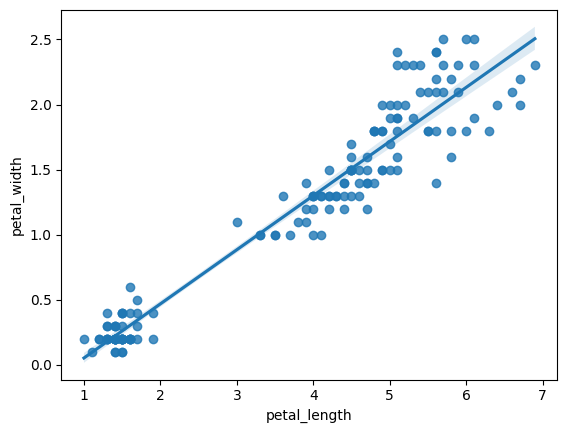

In [60]:
sns.regplot(x='petal_length', y='petal_width', data=iris)
plt.show()

- regplot 사용
  - 마케팅
    - 광고비와 매출
    - 광고 노출 수와 구매수
  - 금융
    - 소득과 소비액
    - 거래 횟수와 총 거래 금액

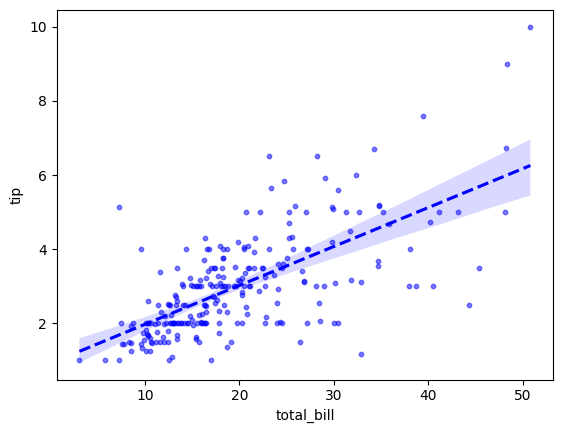

In [63]:
sns.regplot(x='total_bill', y='tip', data=tips, color='blue', line_kws={'linestyle':'--'}, scatter_kws={'s':10, 'alpha':0.5})
plt.show()

### **2.2.4. pairplot : scatter + histogram(혹은 density plot) 확장**

- https://seaborn.pydata.org/generated/seaborn.pairplot.html

- 모든 숫자형 변수들에 대해서 서로 비교하는 산점도 표시
- 각 변수에 대해서는 히스토그램(혹은 density plot) 표시
- 단점 : 시간이 오래 걸린다!



- pairplot( ) 함수 매개변수

    - data : 사용할 데이터프레임

    - hue : 데이터의 카테고리 변수를 기준으로 색상을 다르게 표시하여 그룹 간의 차이를 시각화

    - diag_kind : 대각선에 나타낼 그래프의 종류를 선택

        - auto : 기본값으로, 각 변수의 분포를 히스토그램으로 시각화

        - hist : 각 변수의 분포를 히스토그램으로 시각화

        - kde : 커널 밀도 추정 그래프를 사용하여 각 변수의 분포를 부드럽게 시각화

        - None : 대각선에 아무런 그래프도 표시하지 않도록 설정할 수 있음

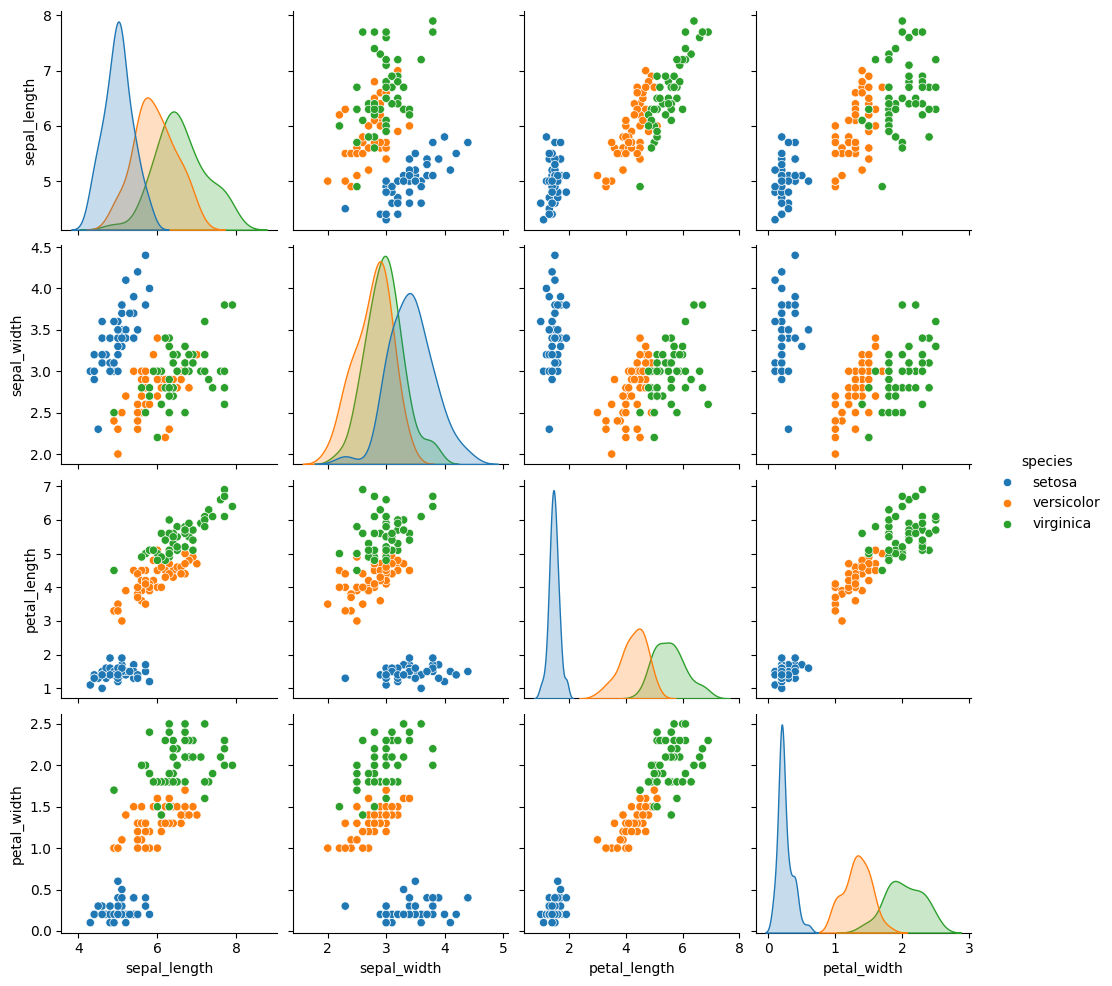

In [64]:
sns.pairplot(iris, hue='species')
plt.show()

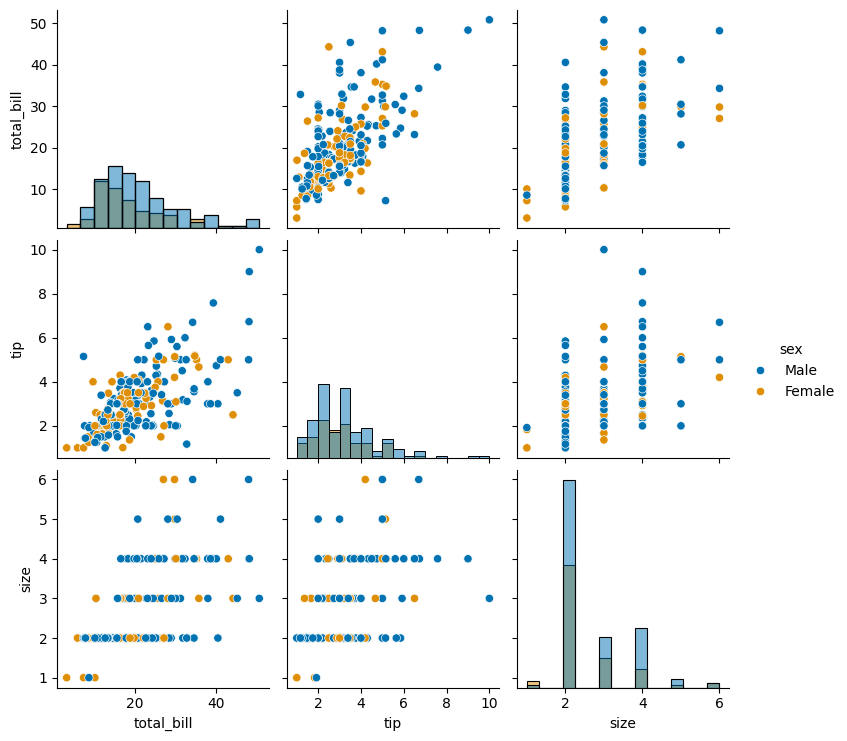

In [66]:
sns.pairplot(tips, hue='sex', diag_kind='hist', palette='colorblind')
plt.show()

### **2.2.5. heatmap : 두 범주 집계 시각화**

- https://seaborn.pydata.org/generated/seaborn.heatmap.html

- 두 범주를 집계한 결과를 색의 농도로 표현해주는 그래프

- 집계(groupby)와 피봇(pivot)을 먼저 만들어 줘야 한다.

- 여러 범주를 갖는 변수 비교 시 유용하다.


- heatmap( ) 함수 매개변수

    - data : 히트맵에 사용할 2차원 데이터

    - annot : 각 셀에 값을 표시할지 여부(기본값:False)

    - fmt : annot=True일 때 숫자 포맷 설정

    - cmap : 색상 팔레트 지정

    - cbar : 컬러바 표시 여부

    - square : 셀을 정사각형으로 표시

In [67]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [68]:
titanic_corr = titanic[['survived', 'sibsp', 'age', 'fare', 'pclass']].corr()
titanic_corr

,survived,sibsp,age,fare,pclass
survived,1.000000,-0.035322,-0.077221,0.257307,-0.338481
sibsp,-0.035322,1.000000,-0.308247,0.159651,0.083081
age,-0.077221,-0.308247,1.000000,0.096067,-0.369226
fare,0.257307,0.159651,0.096067,1.000000,-0.549500
pclass,-0.338481,0.083081,-0.369226,-0.549500,1.000000


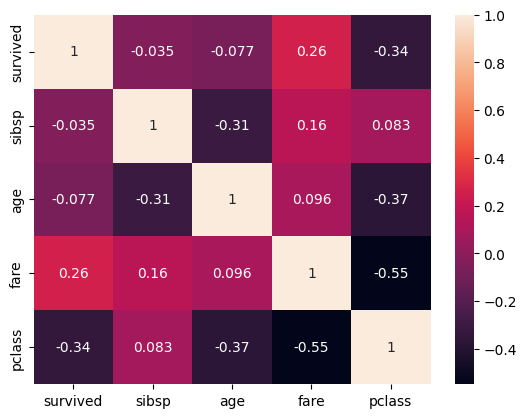

In [69]:
sns.heatmap(data=titanic_corr, annot=True)
plt.show()

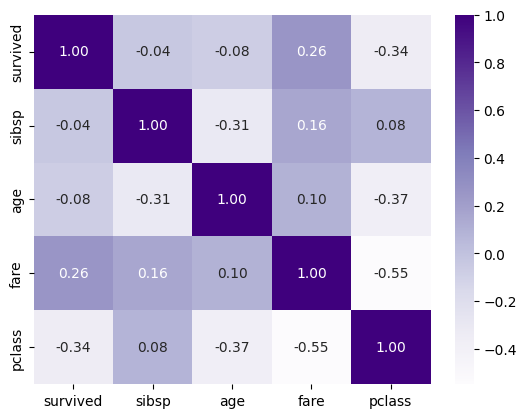

In [70]:
sns.heatmap(data=titanic_corr, annot=True, fmt='.2f', cmap='Purples', cbar=True)
plt.show()

In [71]:
# pivot_table 만들기
titanic_pivot = pd.pivot_table(data=titanic, index='sex', columns='class', values='survived', aggfunc='mean')
titanic_pivot

class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


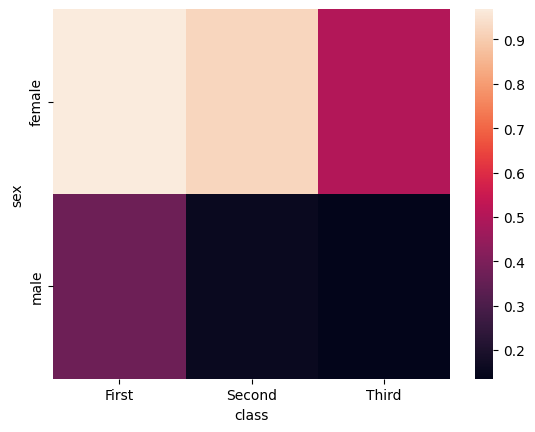

In [73]:
sns.heatmap(data=titanic_pivot) #, annot=True
plt.show()

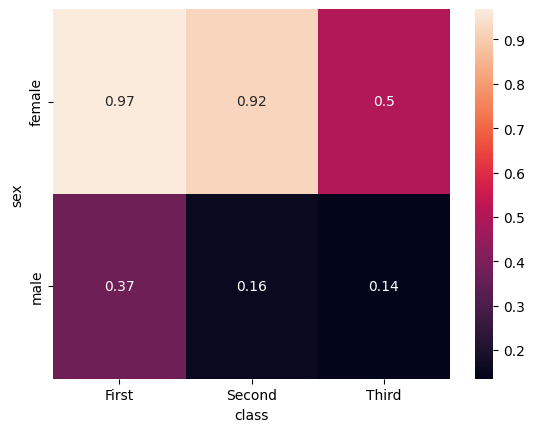

In [75]:
sns.heatmap(data=titanic_pivot, annot=True)
plt.show()

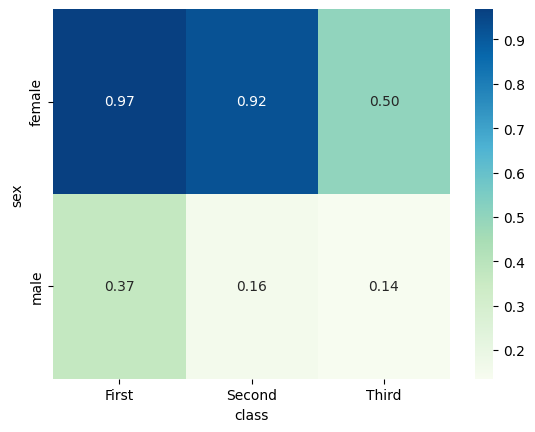

In [77]:
sns.heatmap(data=titanic_pivot, annot=True, fmt='.2f', cmap='GnBu')
plt.show()